# **Rent Analysis in Seoul** 

## **Introduction**

The aim of this analysis is to find the key about why the rentals in South Korea's rental market have been increasing rapidly in recent years, and to identify the factors that contribute to this trend.

This analysis will focus in datasets extracted form Seoul Open Data Plaza (https://data.seoul.go.kr/#), and will include data on rental prices, housing types, and other relevant factors.

The datasets used in this analysis are:
- Seoul Real Estate Jeonse and Monthly Rent Price Information (https://data.seoul.go.kr/dataList/OA-21276/S/1/datasetView.do)

I take the datasets from the years 2022, 2023, 2024 and 2025 , which are the most recent years available in the dataset. All the datasets where merged into one dataset for the analysis and take randomly 400000 rows for the analysis.

The information about the columns from the dataset are the next:
<center>

|Column Name|Column Description|Notes|
|:---|:-------|:-------|
|`registration_year`|Year the contract was registered (file year).|Not the contract year; use `contract_date` for that. A few rows are 2021.|
|`district_code`|Code of the Seoul district (gu).|5 digits. See Lookup_Dongs.|
|`district_name`|District name in English.|Recovered from `district_code` (25 districts).|
|`legal_dong_code`|Code of the legal neighborhood (dong) within the district.|Only unique together with `district_code`.|
|`legal_dong_name`|Neighborhood name, romanized.|Automatic romanization; Korean original in Lookup_Dongs. Blank for a few unmapped codes.|
|`lot_type_code`|Type of lot number: 1, 2 or 3.|Blank for detached / multi-household houses (no lot number in source).|
|`lot_type`|Land lot / Mountain lot / Block lot.|From `lot_type_code`.|
|`main_lot_number`|Main lot number (jibun) of the address.||
|`sub_lot_number`|Sub lot number (jibun) of the address.|0 = none.|
|`floor`|Floor of the unit.|Negative = basement. Blank if not reported.|
|`contract_date`|Date the contract was signed.|Format yyyy-mm-dd.|
|`lease_type`|Jeonse (deposit only) or Monthly rent.|2023: original value. Other years: inferred (monthly rent = 0 -> Jeonse); matches the original in 99.96% of 2023 rows.|
|`leased_area_sqm`|Leased area in square meters (m2).||
|`deposit_10k_krw`|Deposit, in 10,000 KRW.|Example: 16000 = 160,000,000 KRW.|
|`monthly_rent_10k_krw`|Monthly rent, in 10,000 KRW.|0 for Jeonse.|
|`building_name`|Building name (Korean).|Only available for 2023 rows; unrecoverable in 2022/2024/2025 files. Blank when unnamed.|
|`year_built`|Year the building was built.||
|`building_type`|Apartment / Officetel / Row house-Villa / Detached-Multi-household house.|Recovered in all years.|
|`contract_period`|Lease term as YY.MM~YY.MM.|Example: 22.01~24.01 = Jan 2022 to Jan 2024.|
|`contract_type`|New contract or Renewal.|Blank = not specified in source.|
|`renewal_right_used`|Yes if the tenant used the renewal-request right.|Blank = no / not reported.|
|`previous_deposit_10k_krw`|Deposit of the previous contract (renewals), in 10,000 KRW.||
|`previous_monthly_rent_10k_krw`|Monthly rent of the previous contract (renewals), in 10,000 KRW.||

</center>

## **1: Imports** 

These are the libraries used in this analysis:

In [1]:
# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

## **2: Read dataset** 

The method **.read_csv** from the library **pandas** reads a CSV file and returns a DataFrame. It is used to load the dataset into a pandas DataFrame for further analysis.

The syntax is:
pd.read_csv('file_path')

In this analysis, the dataset is loaded from the file path `'C:\\Users\\jamol\\Datasets\\Seoul_Rentals_2022_2025.csv'` and stored in the variable `df`.

In [2]:
df = pd.read_csv('C:\\Users\\jamol\\Datasets\\Seoul_Rentals_2022_2025.csv')

## **3: Data exploration**

In this section, we will explore the dataset to understand its structure and contents. We will start by displaying the first few rows of the dataset using the `head()` method. This will give us a glimpse of the data and help us identify any potential issues or areas for further analysis.

In [3]:
df.head(10)

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,main_lot_number,sub_lot_number,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,building_name,year_built,building_type,contract_period,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
0,2022,11110,Jongno-gu,17500,Sungin-dong,1.0,Land lot,204.0,11.0,8.0,2022-01-01,Jeonse (deposit only),"78,75",24000,0,NaN,1979.0,Apartment,22.01~23.12,Renewal,Yes,23000.0,NaN
1,2022,11170,Yongsan-gu,10200,Yongsan-dong 2-ga,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,30,500,40,NaN,1985.0,Detached / Multi-household house,22.01~24.01,New,NaN,0.0,0.0
2,2022,11170,Yongsan-gu,11100,Cheongpa-dong 3-ga,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,"18,5",1000,40,NaN,1970.0,Detached / Multi-household house,22.01~23.12,New,NaN,0.0,0.0
3,2022,11170,Yongsan-gu,12200,Munbae-dong,1.0,Land lot,24.0,4.0,13.0,2022-01-01,Monthly rent,"17,46",17500,10,NaN,2013.0,Officetel,22.01~22.12,Renewal,NaN,17500.0,0.0
4,2022,11200,Seongdong-gu,10800,Eungbong-dong,1.0,Land lot,265.0,24.0,1.0,2022-01-01,Jeonse (deposit only),"38,19",11000,0,NaN,1992.0,Row house / Villa (multi-unit),NaN,NaN,NaN,NaN,NaN
5,2022,11215,Gwangjin-gu,10100,Junggok-dong,1.0,Land lot,150.0,323.0,1.0,2022-01-01,Monthly rent,"74,49",10000,60,NaN,1997.0,Row house / Villa (multi-unit),22.02~24.02,New,NaN,0.0,0.0
6,2022,11215,Gwangjin-gu,10100,Junggok-dong,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,"23,1",500,30,NaN,1997.0,Detached / Multi-household house,NaN,NaN,NaN,NaN,NaN
7,2022,11215,Gwangjin-gu,10700,Hwayang-dong,1.0,Land lot,111.0,12.0,8.0,2022-01-01,Monthly rent,"16,88",1000,80,NaN,2021.0,Officetel,22.01~23.01,New,NaN,0.0,0.0
8,2022,11215,Gwangjin-gu,10900,Gunja-dong,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,22,1000,47,NaN,2008.0,Detached / Multi-household house,22.01~24.01,New,NaN,0.0,0.0
9,2022,11230,Dongdaemun-gu,10600,Jangan-dong,1.0,Land lot,309.0,7.0,12.0,2022-01-01,Jeonse (deposit only),"54,56",10000,0,NaN,2021.0,Apartment,22.01~24.01,New,NaN,0.0,NaN


The method **.shape** from the library **pandas** returns a tuple representing the dimensionality of the DataFrame. It is used to get the number of rows and columns of the dataset.

The syntax is:
df.shape

In [4]:
df.shape

(400000, 23)

The method **.columns** from the library **pandas** returns the column labels of the DataFrame. It is used to get the names of all columns in the dataset.

The syntax is:
df.columns

In [5]:
df.columns

Index(['registration_year', 'district_code', 'district_name',
       'legal_dong_code', 'legal_dong_name', 'lot_type_code', 'lot_type',
       'main_lot_number', 'sub_lot_number', 'floor', 'contract_date',
       'lease_type', 'leased_area_sqm', 'deposit_10k_krw',
       'monthly_rent_10k_krw', 'building_name', 'year_built', 'building_type',
       'contract_period', 'contract_type', 'renewal_right_used',
       'previous_deposit_10k_krw', 'previous_monthly_rent_10k_krw'],
      dtype='str')

The method **.info()** from the library **pandas** returns a concise summary of the DataFrame. It is used to get information about the DataFrame, including the number of rows, columns, non-null values, and data types.

The syntax is:
df.info()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   registration_year              400000 non-null  int64  
 1   district_code                  400000 non-null  int64  
 2   district_name                  400000 non-null  str    
 3   legal_dong_code                400000 non-null  int64  
 4   legal_dong_name                399988 non-null  str    
 5   lot_type_code                  299849 non-null  float64
 6   lot_type                       299849 non-null  str    
 7   main_lot_number                299976 non-null  float64
 8   sub_lot_number                 299976 non-null  float64
 9   floor                          299870 non-null  float64
 10  contract_date                  400000 non-null  str    
 11  lease_type                     400000 non-null  str    
 12  leased_area_sqm                400000 non

The method **.describe()** from the library **pandas** returns a statistical summary of the DataFrame. It is used to get descriptive statistics of the numerical columns in the dataset, including count, mean, standard deviation, minimum, maximum, and quartile values.

The syntax is:
df.describe()

In [7]:
df.describe()

,registration_year,district_code,legal_dong_code,lot_type_code,main_lot_number,sub_lot_number,floor,deposit_10k_krw,monthly_rent_10k_krw,year_built,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
count,400000.000000,400000.000000,400000.000000,299849.000000,299976.000000,299976.000000,299870.000000,400000.000000,400000.000000,387350.000000,2.169010e+05,1.069690e+05
mean,2023.500047,11473.243000,10941.825750,1.001998,518.486422,19.689475,7.528572,22838.000328,38.489715,2005.419246,1.118895e+06,1.831622e+03
std,1.118013,182.658818,1242.499795,0.059170,519.926969,89.991567,5.930113,28579.681414,65.651234,16.042567,2.628782e+07,4.933894e+04
min,2021.000000,11110.000000,10100.000000,1.000000,0.000000,0.000000,-4.000000,0.000000,0.000000,1006.000000,0.000000e+00,0.000000e+00
25%,2023.000000,11305.000000,10200.000000,1.000000,140.000000,0.000000,3.000000,2636.750000,0.000000,1995.000000,0.000000e+00,0.000000e+00
50%,2023.500000,11500.000000,10600.000000,1.000000,413.000000,1.000000,6.000000,14000.000000,15.000000,2007.000000,0.000000e+00,0.000000e+00
75%,2024.250000,11620.000000,11000.000000,1.000000,742.000000,11.000000,11.000000,30500.000000,56.000000,2017.000000,2.000000e+04,2.500000e+01
max,2025.000000,11740.000000,18700.000000,3.000000,4975.000000,4143.000000,302.000000,810000.000000,4000.000000,7811.000000,2.200000e+09,4.280000e+06


### **Check for missing values**

When using the methods **.isna()** and **.sum()** on a DataFrame, you get the count of missing values per column. 

The syntax is:
df.isna().sum()

In [8]:
df.isna().sum()

registration_year                     0
district_code                         0
district_name                         0
legal_dong_code                       0
legal_dong_name                      12
lot_type_code                    100151
lot_type                         100151
main_lot_number                  100024
sub_lot_number                   100024
floor                            100130
contract_date                         0
lease_type                            0
leased_area_sqm                       0
deposit_10k_krw                       0
monthly_rent_10k_krw                  0
building_name                    309247
year_built                        12650
building_type                         0
contract_period                   54099
contract_type                     51380
renewal_right_used               363931
previous_deposit_10k_krw         183099
previous_monthly_rent_10k_krw    293031
dtype: int64

### **Check duplicates**

When using the methods **.duplicated()** and **.sum()** on a DataFrame, you get the count of duplicate rows. 

The syntax is:
df.duplicated().sum()

In [9]:
df.duplicated().sum()

np.int64(10)

In [10]:
df[df.duplicated()]

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,main_lot_number,sub_lot_number,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,building_name,year_built,building_type,contract_period,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
210303,2024,11410,Seodaemun-gu,11700,Yeonhui-dong,NaN,NaN,NaN,NaN,NaN,2024-01-22,Monthly rent,"17,5",500,35,NaN,NaN,Detached / Multi-household house,24.02~25.02,New,NaN,NaN,NaN
210875,2024,11215,Gwangjin-gu,10400,Gwangjang-dong,NaN,NaN,NaN,NaN,NaN,2024-01-24,Monthly rent,20,500,40,NaN,NaN,Detached / Multi-household house,24.02~26.02,New,NaN,NaN,NaN
229130,2024,11590,Dongjak-gu,10500,Heukseok-dong,1.0,Land lot,341.0,0.0,3.0,2024-03-25,Jeonse (deposit only),"84,91",100000,0,NaN,2019.0,Apartment,24.04~26.02,New,NaN,NaN,NaN
305752,2025,11230,Dongdaemun-gu,10500,Dapsipri-dong,1.0,Land lot,66.0,112.0,3.0,2025-01-12,Jeonse (deposit only),"82,31",50000,0,NaN,2024.0,Officetel,25.02~27.02,New,NaN,NaN,NaN
307559,2025,11200,Seongdong-gu,11500,Seongsu-dong 2-ga,1.0,Land lot,843.0,0.0,9.0,2025-01-18,Monthly rent,"57,49",10000,300,NaN,2009.0,Apartment,25.02~27.02,New,NaN,NaN,NaN
320234,2025,11230,Dongdaemun-gu,10500,Dapsipri-dong,1.0,Land lot,66.0,112.0,5.0,2025-02-28,Monthly rent,"82,31",20000,165,NaN,2024.0,Officetel,25.03~27.03,New,NaN,NaN,NaN
365567,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,32.0,2025-08-10,Jeonse (deposit only),"84,981",80000,0,NaN,2023.0,Apartment,25.10~27.10,New,NaN,NaN,NaN
366596,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,41.0,2025-08-14,Jeonse (deposit only),"84,983",68000,0,NaN,2023.0,Apartment,25.09~25.11,Renewal,NaN,68000.0,NaN
368382,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,7.0,2025-08-21,Jeonse (deposit only),"84,993",63000,0,NaN,2023.0,Apartment,25.09~27.09,Renewal,Yes,60000.0,NaN
370068,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,46.0,2025-08-27,Monthly rent,"84,981",33900,180,NaN,2023.0,Apartment,25.10~27.10,Renewal,NaN,30000.0,180.0


### **Check cathegorical columns**

The method **.value__counts()** from the library **pandas** returns a Series containing counts of unique values. It is used to get the frequency of each unique value in a column of the DataFrame.

The syntax is:
df['column_name'].value_counts()

- `df['lease_type'].value_counts()` returns the frequency of each unique value in the `lease_type` column.
- `df['registration_year'].value_counts()` returns the frequency of each unique value in the `registration_year` column.
- `df['building_type'].value_counts()` returns the frequency of each unique value in the `building_type` column.

In [11]:
df['lease_type'].value_counts()

lease_type
Monthly rent             219690
Jeonse (deposit only)    180310
Name: count, dtype: int64

In [12]:
df['registration_year'].value_counts()

registration_year
2023    100028
2024    100000
2025    100000
2022     99963
2021         9
Name: count, dtype: int64

In [13]:
df['building_type'].value_counts()

building_type
Apartment                           162006
Detached / Multi-household house    100130
Row house / Villa (multi-unit)       86481
Officetel                            51383
Name: count, dtype: int64

## **Data cleaning**

Let's revise more columns to clean the data...

In [19]:
df.isna().sum()

registration_year                     0
district_code                         0
district_name                         0
legal_dong_code                       0
legal_dong_name                      12
lot_type_code                    100151
lot_type                         100151
main_lot_number                  100024
sub_lot_number                   100024
floor                            100130
contract_date                         0
lease_type                            0
leased_area_sqm                       0
deposit_10k_krw                       0
monthly_rent_10k_krw                  0
building_name                    309247
year_built                        12650
building_type                         0
contract_period                   54099
contract_type                     51380
renewal_right_used               363931
previous_deposit_10k_krw         183099
previous_monthly_rent_10k_krw    293031
dtype: int64

We can see that there are missing values in the main DataFrame (df). To handle this, we can create a copy of the DataFrame and drop the rows with missing values. This will allow us to work with a clean dataset for our analysis.

In [20]:
df_copy = df.copy()

df_copy['legal_dong_name'] = df_copy['legal_dong_name'].fillna('Unknown')
df_copy = df_copy.drop(['building_name', 'main_lot_number', 'sub_lot_number'], axis=1)
df_copy['lot_type_code'] = df_copy['lot_type_code'].fillna(0.0)
df_copy['lot_type'] = df_copy['lot_type'].fillna('No lot type')
df_copy['floor_reported'] = df_copy['floor'].notna()
df_copy['contract_type'] = df_copy['contract_type'].fillna('Not specified')
df_copy['renewal_right_used'] = df_copy['renewal_right_used'].fillna('No/Not reported')
df_copy = df_copy.dropna(subset=['contract_period'], axis=0)

#Critical columns
df_copy = df_copy.dropna(subset=['year_built'])

#Divide the contract_period into two separate columns: contract_start and contract_end
periods = df_copy['contract_period'].str.split('~', expand=True)

pos = df_copy.columns.get_loc('contract_period') + 1

df_copy.insert(pos, 'contract_start', pd.to_datetime(periods[0], format='%y.%m', errors='coerce'))
df_copy.insert(pos + 1, 'contract_end', pd.to_datetime(periods[1], format='%y.%m', errors='coerce'))

df_copy = df_copy.dropna(subset=['contract_start'], axis=0)
df_copy = df_copy.dropna(subset=['contract_end'], axis=0)

df_copy.head(10)

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,year_built,building_type,contract_period,contract_start,contract_end,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw,floor_reported
0,2022,11110,Jongno-gu,17500,Sungin-dong,1.0,Land lot,8.0,2022-01-01,Jeonse (deposit only),"78,75",24000,0,1979.0,Apartment,22.01~23.12,2022-01-01,2023-12-01,Renewal,Yes,23000.0,NaN,True
1,2022,11170,Yongsan-gu,10200,Yongsan-dong 2-ga,0.0,No lot type,NaN,2022-01-01,Monthly rent,30,500,40,1985.0,Detached / Multi-household house,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,0.0,False
2,2022,11170,Yongsan-gu,11100,Cheongpa-dong 3-ga,0.0,No lot type,NaN,2022-01-01,Monthly rent,"18,5",1000,40,1970.0,Detached / Multi-household house,22.01~23.12,2022-01-01,2023-12-01,New,No/Not reported,0.0,0.0,False
3,2022,11170,Yongsan-gu,12200,Munbae-dong,1.0,Land lot,13.0,2022-01-01,Monthly rent,"17,46",17500,10,2013.0,Officetel,22.01~22.12,2022-01-01,2022-12-01,Renewal,No/Not reported,17500.0,0.0,True
5,2022,11215,Gwangjin-gu,10100,Junggok-dong,1.0,Land lot,1.0,2022-01-01,Monthly rent,"74,49",10000,60,1997.0,Row house / Villa (multi-unit),22.02~24.02,2022-02-01,2024-02-01,New,No/Not reported,0.0,0.0,True
7,2022,11215,Gwangjin-gu,10700,Hwayang-dong,1.0,Land lot,8.0,2022-01-01,Monthly rent,"16,88",1000,80,2021.0,Officetel,22.01~23.01,2022-01-01,2023-01-01,New,No/Not reported,0.0,0.0,True
8,2022,11215,Gwangjin-gu,10900,Gunja-dong,0.0,No lot type,NaN,2022-01-01,Monthly rent,22,1000,47,2008.0,Detached / Multi-household house,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,0.0,False
9,2022,11230,Dongdaemun-gu,10600,Jangan-dong,1.0,Land lot,12.0,2022-01-01,Jeonse (deposit only),"54,56",10000,0,2021.0,Apartment,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,NaN,True
10,2022,11230,Dongdaemun-gu,10800,Hoegi-dong,0.0,No lot type,NaN,2022-01-01,Monthly rent,30,250,40,1992.0,Detached / Multi-household house,22.01~23.01,2022-01-01,2023-01-01,New,No/Not reported,0.0,0.0,False
11,2022,11230,Dongdaemun-gu,10900,Hwigyeong-dong,0.0,No lot type,NaN,2022-01-01,Monthly rent,"18,73",1000,70,2017.0,Detached / Multi-household house,22.02~23.02,2022-02-01,2023-02-01,New,No/Not reported,0.0,0.0,False


In [21]:
df_copy.shape

(331897, 23)

In [22]:
df_copy.isna().sum()

registration_year                     0
district_code                         0
district_name                         0
legal_dong_code                       0
legal_dong_name                       0
lot_type_code                         0
lot_type                              0
floor                             74112
contract_date                         0
lease_type                            0
leased_area_sqm                       0
deposit_10k_krw                       0
monthly_rent_10k_krw                  0
year_built                            0
building_type                         0
contract_period                       0
contract_start                        0
contract_end                          0
contract_type                         0
renewal_right_used                    0
previous_deposit_10k_krw         126580
previous_monthly_rent_10k_krw    231492
floor_reported                        0
dtype: int64

We need to revise if the **df_copy** have duplicated values in order to delete them

In [26]:
df_copy[df_copy.duplicated()]

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,year_built,building_type,contract_period,contract_start,contract_end,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw,floor_reported
53481,2022,11650,Seocho-gu,10200,Yangjae-dong,1.0,Land lot,4.0,2022-06-20,Monthly rent,"45,04",100,88,2021.0,Row house / Villa (multi-unit),22.06~24.09,2022-06-01,2024-09-01,New,No/Not reported,0.0,0.0,True
219957,2024,11620,Gwanak-gu,10100,Bongcheon-dong,1.0,Land lot,18.0,2024-02-24,Jeonse (deposit only),"84,93",70000,0,2019.0,Apartment,24.03~26.03,2024-03-01,2026-03-01,New,No/Not reported,NaN,NaN,True
229130,2024,11590,Dongjak-gu,10500,Heukseok-dong,1.0,Land lot,3.0,2024-03-25,Jeonse (deposit only),"84,91",100000,0,2019.0,Apartment,24.04~26.02,2024-04-01,2026-02-01,New,No/Not reported,NaN,NaN,True
305752,2025,11230,Dongdaemun-gu,10500,Dapsipri-dong,1.0,Land lot,3.0,2025-01-12,Jeonse (deposit only),"82,31",50000,0,2024.0,Officetel,25.02~27.02,2025-02-01,2027-02-01,New,No/Not reported,NaN,NaN,True
307559,2025,11200,Seongdong-gu,11500,Seongsu-dong 2-ga,1.0,Land lot,9.0,2025-01-18,Monthly rent,"57,49",10000,300,2009.0,Apartment,25.02~27.02,2025-02-01,2027-02-01,New,No/Not reported,NaN,NaN,True
311227,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,8.0,2025-02-03,Monthly rent,"59,84",69450,100,2023.0,Apartment,25.03~27.03,2025-03-01,2027-03-01,Renewal,No/Not reported,65000.0,100.0,True
313103,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,11.0,2025-02-08,Monthly rent,"59,98",10000,359,2023.0,Apartment,25.04~27.04,2025-04-01,2027-04-01,Renewal,Yes,10000.0,340.0,True
313105,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,5.0,2025-02-08,Jeonse (deposit only),"78,77",92400,0,2023.0,Apartment,25.02~27.02,2025-02-01,2027-02-01,Renewal,Yes,88000.0,NaN,True
315190,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,4.0,2025-02-14,Jeonse (deposit only),"78,77",150000,0,2023.0,Apartment,25.04~27.04,2025-04-01,2027-04-01,New,No/Not reported,NaN,NaN,True
315796,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,7.0,2025-02-15,Monthly rent,"59,84",63000,100,2023.0,Apartment,25.03~27.03,2025-03-01,2027-03-01,Renewal,Yes,60000.0,95.0,True


To eliminate duplicates, we can use the **drop_duplicates()** method. This will remove any duplicate rows from the DataFrame, keeping only the first occurrence of each duplicate. 

In [27]:
df_copy.drop_duplicates()
df_copy.shape

(331897, 23)

### **Show and remove outliers**

Using the **.describe()** method we can see that the statistical summary of the numerical columns in the dataset, including count, mean, standard deviation, minimum, maximum, and quartile values.

For example, the year_built column has a mean of around **2005**, which means that the average building in the dataset was built in 2005. The minimum value is **1006** and the maximum value is **7811**, which seems unusual and may indicate data entry errors or outliers in the dataset.

In [29]:
column = 'year_built'

Q1 = df_copy[column].quantile(0.25)
Q3 = df_copy[column].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy[column] < lower_limit) | (df_copy[column] > upper_limit)]

print(f"Number of outliers found: {len(outliers)}")

Number of outliers found: 499


A good way to see the outliers visualy is to plot diagrams. A **box plot** is a great way to visualize the distribution of data and identify outliers. Moreover, a **histogram** is useful for understanding the frequency distribution of data.

Let's plot box plots for the numerical columns in the dataset to identify outliers visually.

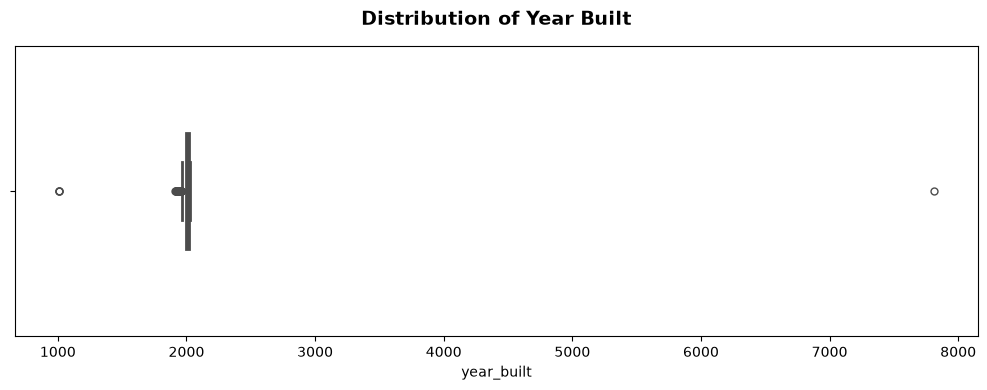

In [30]:
# Box plot 
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df[column], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Distribution of Year Built', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(column)

plt.tight_layout()
plt.show()

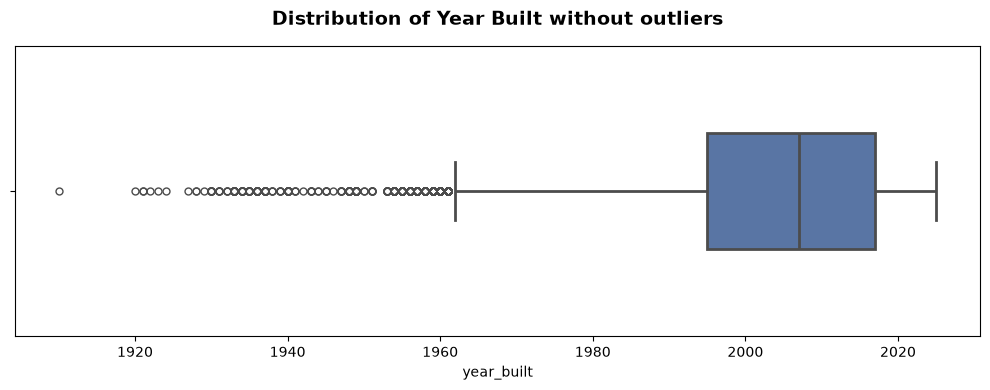

In [31]:
df_clean = df[(df['year_built'] >= 1850) & (df['year_built'] <= 2026)]

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_clean[column], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Distribution of Year Built without outliers', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(column)

plt.tight_layout()
plt.show()

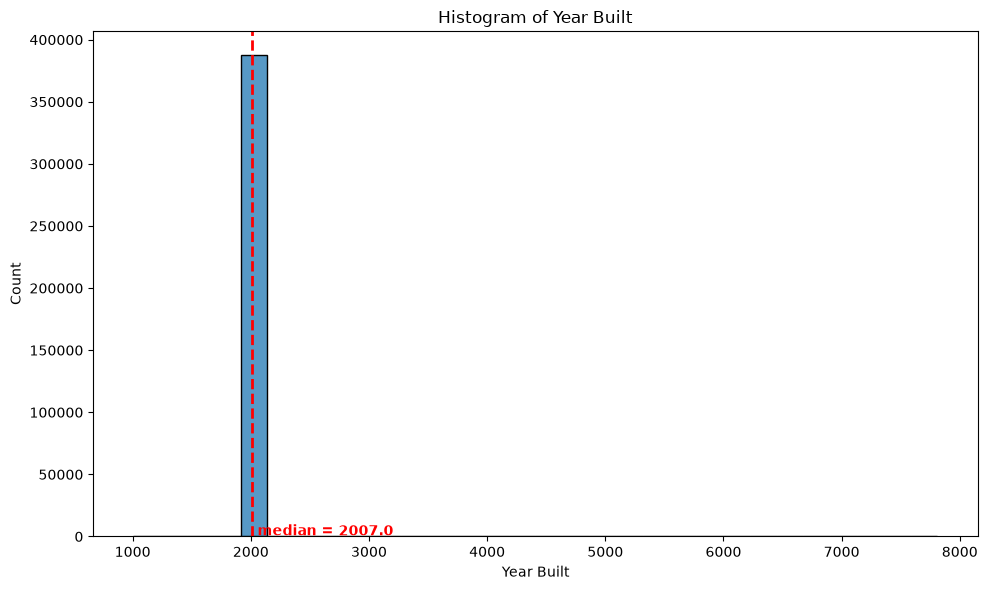

In [32]:
#Histogram
plt.figure(figsize=(10, 6))
sns.histplot(x=df[column], bins=30)

median_year = df[column].median()
plt.axvline(median_year, color='red', linestyle='--', linewidth=2)

plt.text(median_year + 50, 1000, f'median = {median_year}', color='red', fontweight='bold')

plt.title('Histogram of Year Built')
plt.xlabel('Year Built')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

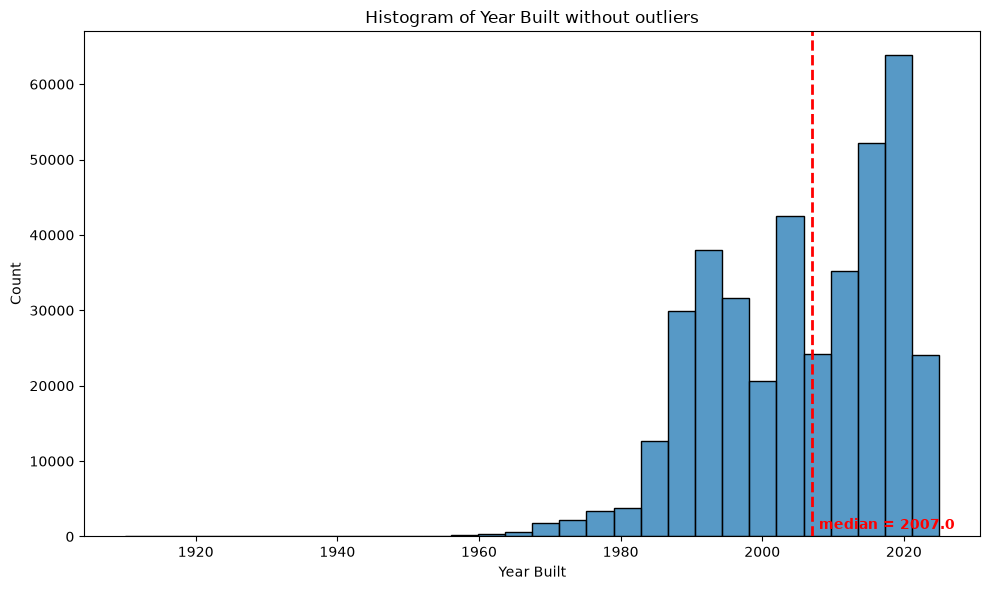

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_clean[column], bins=30)

median_year = df_clean[column].median()
plt.axvline(median_year, color='red', linestyle='--', linewidth=2)

plt.text(median_year + 1, 1000, f'median = {median_year}', color='red', fontweight='bold')

plt.title('Histogram of Year Built without outliers')
plt.xlabel('Year Built')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

We need to calculate the **minimum** and **maximum** values for the 'year_built' column in the cleaned dataset. 

In [35]:
print(f"Minimum built year: {df_copy['year_built'].min()}")
print(f"Maximum built year: {df_copy['year_built'].max()}")

Minimum built year: 1006.0
Maximum built year: 7811.0


### **Remove invalid values in `year_built`**

The IQR method flagged extreme values in `year_built`, but a statistical rule alone is not enough to decide which of them are errors. Some extreme values are impossible (the `.describe()` summary showed a minimum of 1006 and a maximum of 7811), while others may be real, old buildings that simply sit far from the median.

Instead of removing every value flagged by the IQR, I used a **logical range** based on domain knowledge:

- **Upper limit (2026):** a building cannot have been built in the future, so any year after 2026 is a data entry error.
- **Lower limit (1850):** residential buildings in Seoul built before this year are not plausible in a rental dataset. Values such as 1006 or 1011 are clearly typos. The limit is intentionally permissive so that genuinely old buildings are not discarded by mistake.

Rows outside the range 1850–2026 are removed. The number of rows dropped is printed to document the impact of this decision.

In [36]:
MIN_YEAR = 1850
MAX_YEAR = 2026

rows_before = len(df_copy)

# Rows that will be removed (for documentation)
invalid_years = df_copy[~df_copy['year_built'].between(MIN_YEAR, MAX_YEAR)]
print(f"Invalid year_built values found: {len(invalid_years):,}")
print(invalid_years['year_built'].value_counts().sort_index().head(20))

# Keep only rows inside the valid range
df_copy = df_copy[df_copy['year_built'].between(MIN_YEAR, MAX_YEAR)].reset_index(drop=True)

print(f"\nRows before: {rows_before:,} | Rows after: {len(df_copy):,}")
print(f"Rows dropped: {rows_before - len(df_copy):,} ({(rows_before - len(df_copy)) / rows_before * 100:.2f}%)")
print(f"year_built range now: {df_copy['year_built'].min():.0f} - {df_copy['year_built'].max():.0f}")

Invalid year_built values found: 4
year_built
1006.0    3
7811.0    1
Name: count, dtype: int64

Rows before: 331,897 | Rows after: 331,893
Rows dropped: 4 (0.00%)
year_built range now: 1910 - 2025
